In [ ]:
# 셀 1: GCS 인증 
from google.colab import auth
auth.authenticate_user()

PROJECT_ID  = 'project-id'
BUCKET_NAME = 'sign-language-data-2026'

!gcloud config set project {PROJECT_ID}
print('GCS 인증 완료')

In [ ]:
# 셀 2: 라이브러리 및 데이터 로드 
import numpy as np
import json
import io
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from google.cloud import storage

client = storage.Client()
bucket = client.bucket(BUCKET_NAME)

def load_npy(blob_name):
    buf = io.BytesIO(bucket.blob(blob_name).download_as_bytes())
    return np.load(buf)

X = load_npy('processed/X_train_DFU.npy')  # (9000, 30, 274)
y = load_npy('processed/y_train_DFU.npy')  # (9000,)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

GCS에서 데이터 로드 중...
X shape: (9000, 30, 274)
y shape: (9000,)
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 셀 3: 정규화 + 데이터 분리
NUM_CLASSES = 3000

X_mean = X.mean(axis=(0, 1), keepdims=True)
X_std  = X.std(axis=(0, 1),  keepdims=True) + 1e-8
X_norm = (X - X_mean) / X_std

# stratify 불가 (샘플 9000 < 클래스 3000 × 분리비율)
# batch_02, 03 추가 후 stratify 적용 예정
X_train, X_temp, y_train, y_temp = train_test_split( # 80 / 10/ 10
    X_norm, y, test_size=0.20, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

y_val_cat  = to_categorical(y_val,  NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (7200, 30, 274), Val: (900, 30, 274), Test: (900, 30, 274)


In [ ]:
# 셀 4: 데이터 증강 (3배) 
def augment(x):
    noise = np.random.normal(0, 0.01, x.shape)
    scale = np.random.uniform(0.9, 1.1)
    shift = np.random.uniform(-0.05, 0.05)
    return x * scale + noise + shift

X_aug1 = np.array([augment(x) for x in X_train])
X_aug2 = np.array([augment(x) for x in X_train])

X_train_final = np.concatenate([X_train, X_aug1, X_aug2], axis=0)
y_train_final = np.concatenate([y_train, y_train, y_train], axis=0)
y_train_final_cat = to_categorical(y_train_final, NUM_CLASSES)

print(f'원본 train: {X_train.shape}')
print(f'증강 후:    {X_train_final.shape}  (3배)')

원본 train: (7200, 30, 274)
증강 후:    (21600, 30, 274)  (3배)


In [ ]:
# 셀 5: 모델 정의 
def positional_encoding(length, depth):
    positions = tf.range(length, dtype=tf.float32)[:, tf.newaxis]
    dims      = tf.range(depth,  dtype=tf.float32)[tf.newaxis, :]
    angles    = positions / tf.pow(10000.0, (2 * (dims // 2)) / tf.cast(depth, tf.float32))
    angles    = tf.concat([tf.sin(angles[:, 0::2]), tf.cos(angles[:, 1::2])], axis=-1)
    return angles[tf.newaxis, :, :]

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att   = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn   = models.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.att(x, x)
        x    = self.norm1(x + self.drop1(attn, training=training))
        ffn  = self.ffn(x)
        x    = self.norm2(x + self.drop2(ffn,  training=training))
        return x

def build_model(input_shape=(30, 274), num_classes=3000,
                embed_dim=128, num_heads=4, ff_dim=256,
                num_blocks=3, dropout=0.1):
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(embed_dim)(inputs)
    x = x + positional_encoding(input_shape[0], embed_dim)
    for _ in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

model = build_model()
model.summary()
print(f'\nGPU: {tf.config.list_physical_devices("GPU")}')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 274)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30, 128)        │        35,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 30, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 30, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 30, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3000)           │       771,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,236,664 (4.72 MB)

 Trainable params: 1,236,664 (4.72 MB)

 Non-trainable params: 0 (0.00 B)


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 셀 6: 학습 
# 변경 2: batch_size 64 -> 32
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_model_v4.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
]

history = model.fit(
    X_train_final, y_train_final_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=32,   # ← 64 -> 32 변경
    callbacks=callbacks
)

Epoch 1/100
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 7.3275e-04 - loss: 7.9193 - top5_acc: 0.0021
Epoch 1: val_accuracy improved from None to 0.00000, saving model to /content/best_model_v4.h5



Epoch 1: finished saving model to /content/best_model_v4.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 5.5556e-04 - loss: 7.7399 - top5_acc: 0.0028 - val_accuracy: 0.0000e+00 - val_loss: 7.9404 - val_top5_acc: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
667/675 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0026 - loss: 6.9567 - top5_acc: 0.0129
Epoch 2: val_accuracy did not improve from 0.00000
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0031 - loss: 6.7802 - top5_acc: 0.0159 - val_accuracy: 0.0000e+00 - val_loss: 7.4517 - val_top5_acc: 0.0022 - learning_rate: 0.0010
Epoch 3/100
673/675 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0092 - loss: 6.0313 - top5_acc: 0.0408
Epoch 3: val_accuracy improved from 0.00000 to 0.00556, saving model to /content/best_model_v4.h5



Epoch 3: finished saving model to /content/best_model_v4.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.0106 - loss: 5.8491 - top5_acc: 0.0507 - val_accuracy: 0.0056 - val_loss: 6.4359 - val_top5_acc: 0.0211 - learning_rate: 0.0010
Epoch 4/100
669/675 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0267 - loss: 5.2016 - top5_acc: 0.1093
Epoch 4: val_accuracy improved from 0.00556 to 0.01778, saving model to /content/best_model_v4.h5



Epoch 4: finished saving model to /content/best_model_v4.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0312 - loss: 5.0562 - top5_acc: 0.1223 - val_accuracy: 0.0178 - val_loss: 5.5876 - val_top5_acc: 0.0867 - learning_rate: 0.0010
Epoch 5/100
670/675 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0541 - loss: 4.5147 - top5_acc: 0.2027
Epoch 5: val_accuracy improved from 0.01778 to 0.03556, saving model to /content/best_model_v4.h5



Epoch 5: finished saving model to /content/best_model_v4.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0609 - loss: 4.3985 - top5_acc: 0.2212 - val_accuracy: 0.0356 - val_loss: 4.9692 - val_top5_acc: 0.1656 - learning_rate: 0.0010
Epoch 6/100
670/675 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0984 - loss: 3.9492 - top5_acc: 0.3161
Epoch 6: val_accuracy improved from 0.03556 to 0.08222, saving model to /content/best_model_v4.h5


...


Epoch 72: finished saving model to /content/best_model_v4.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9889 - loss: 0.0315 - top5_acc: 0.9999 - val_accuracy: 0.9078 - val_loss: 1.0916 - val_top5_acc: 0.9733 - learning_rate: 2.5000e-04
Epoch 73/100
670/675 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9943 - loss: 0.0169 - top5_acc: 1.0000
Epoch 73: val_accuracy improved from 0.90778 to 0.92000, saving model to /content/best_model_v4.h5



Epoch 73: finished saving model to /content/best_model_v4.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9949 - loss: 0.0155 - top5_acc: 1.0000 - val_accuracy: 0.9200 - val_loss: 1.0353 - val_top5_acc: 0.9733 - learning_rate: 1.2500e-04
Epoch 74/100
671/675 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9949 - loss: 0.0151 - top5_acc: 1.0000
Epoch 74: val_accuracy did not improve from 0.92000
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9955 - loss: 0.0143 - top5_acc: 1.0000 - val_accuracy: 0.9200 - val_loss: 1.0321 - val_top5_acc: 0.9722 - learning_rate: 1.2500e-04
Epoch 75/100
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9964 - loss: 0.0134 - top5_acc: 1.0000
Epoch 75: val_accuracy did not improve from 0.92000
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9959 - loss: 0.0137 - top5_acc: 1.0000 - val_accuracy: 0.9189 - val_loss: 1.0387 - val_top5_acc: 0.9711 - learning_rate: 1.2500e-04
Epoch 76/100
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - ac


Epoch 78: finished saving model to /content/best_model_v4.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9970 - loss: 0.0111 - top5_acc: 1.0000 - val_accuracy: 0.9244 - val_loss: 1.0435 - val_top5_acc: 0.9722 - learning_rate: 6.2500e-05
Epoch 79/100
672/675 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9977 - loss: 0.0087 - top5_acc: 1.0000
Epoch 79: val_accuracy did not improve from 0.92444
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9980 - loss: 0.0080 - top5_acc: 1.0000 - val_accuracy: 0.9233 - val_loss: 1.0346 - val_top5_acc: 0.9722 - learning_rate: 6.2500e-05
Epoch 80/100
672/675 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9986 - loss: 0.0065 - top5_acc: 1.0000
Epoch 80: val_accuracy did not improve from 0.92444
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9981 - loss: 0.0076 - top5_acc: 1.0000 - val_accuracy: 0.9200 - val_loss: 1.0432 - val_top5_acc: 0.9722 - learning_rate: 6.2500e-05
Epoch 81/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc


Epoch 82: finished saving model to /content/best_model_v4.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9978 - loss: 0.0081 - top5_acc: 1.0000 - val_accuracy: 0.9256 - val_loss: 1.0504 - val_top5_acc: 0.9722 - learning_rate: 6.2500e-05
Epoch 83/100
668/675 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0080 - top5_acc: 1.0000
Epoch 83: val_accuracy did not improve from 0.92556
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9981 - loss: 0.0080 - top5_acc: 1.0000 - val_accuracy: 0.9211 - val_loss: 1.0498 - val_top5_acc: 0.9722 - learning_rate: 3.1250e-05
Epoch 84/100
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0073 - top5_acc: 1.0000
Epoch 84: val_accuracy did not improve from 0.92556
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9982 - loss: 0.0075 - top5_acc: 1.0000 - val_accuracy: 0.9256 - val_loss: 1.0424 - val_top5_acc: 0.9722 - learning_rate: 3.1250e-05
Epoch 85/100
667/675 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc


Epoch 85: finished saving model to /content/best_model_v4.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9980 - loss: 0.0074 - top5_acc: 1.0000 - val_accuracy: 0.9322 - val_loss: 1.0307 - val_top5_acc: 0.9722 - learning_rate: 3.1250e-05
Epoch 86/100
672/675 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9984 - loss: 0.0062 - top5_acc: 1.0000
Epoch 86: val_accuracy did not improve from 0.93222
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9983 - loss: 0.0066 - top5_acc: 1.0000 - val_accuracy: 0.9289 - val_loss: 1.0435 - val_top5_acc: 0.9722 - learning_rate: 3.1250e-05
Epoch 87/100
672/675 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9979 - loss: 0.0075 - top5_acc: 0.9999
Epoch 87: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 87: val_accuracy did not improve from 0.93222
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9980 - loss: 0.0072 - top5_acc: 1.0000 - val_accuracy: 0.9300 - val_loss: 1.0392 - val_top5_acc: 0.9722 - learni


[최종 성능]
  Test Top-1: 0.9133 (91.3%)
  Test Top-5: 0.9644 (96.4%)


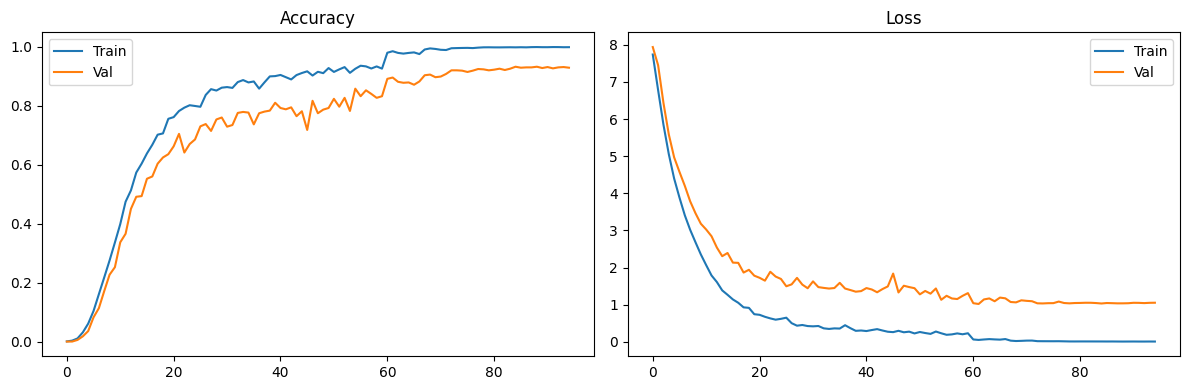

In [ ]:
# 셀 7: 평가 
import matplotlib.pyplot as plt

test_loss, test_acc, test_top5 = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'\n[최종 성능]')
print(f'  Test Top-1: {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'  Test Top-5: {test_top5:.4f} ({test_top5*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('/content/training_curve_v4.png', dpi=150)
plt.show()

In [ ]:
# 셀 8: GCS 저장 
from google.cloud import storage

def upload_to_gcs(local_path, blob_name):
    bucket.blob(blob_name).upload_from_filename(local_path)
    print(f'  ● {blob_name}')

np.save('/content/X_mean_v4.npy', X_mean)
np.save('/content/X_std_v4.npy',  X_std)

print('GCS 업로드 중...')
upload_to_gcs('/content/best_model_v4.h5',      'models/lstm_model_v4.h5')
upload_to_gcs('/content/X_mean_v4.npy',         'models/X_mean_v4.npy')
upload_to_gcs('/content/X_std_v4.npy',          'models/X_std_v4.npy')
upload_to_gcs('/content/training_curve_v4.png', 'models/training_curve_v4.png')
print('\n● 완료')